In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df

README.md: 0.00B [00:00, ?B/s]

c:\Users\Varsha\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Varsha\.cache\huggingface\hub\datasets--lukebarousse--data_jobs. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,None,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,None,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,None,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,None,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [2]:
#cleaning the job_skills column by converting them from strings into lists
import ast
df['job_skills']=df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills )

In [3]:
#creating a new dataframe that displays only data engineer jobs
df_new=df[df['job_title_short']=='Data Engineer'].copy()


In [4]:
#creating a month column
df_new['month']=df_new['job_posted_date'].dt.strftime('%b')

In [5]:
#exploding the job skills column
df_new=df_new.explode('job_skills')

In [6]:
#creating a pivot table that groups months and job skills, nan values are filled with 0
df_pivot=df_new.pivot_table(index='month', columns='job_skills', aggfunc='size',fill_value=0)
#creating a month no column
df_pivot.reset_index(inplace=True)
df_pivot['month_no']=pd.to_datetime(df_pivot['month'], format='%b').dt.month
#setting the month no as index and sorting it to obtain chronologically ordered months
df_pivot.set_index('month_no', inplace=True)
df_pivot.sort_index(inplace=True)
#resetting the index and dropping the month no column
df_pivot.reset_index(inplace=True)
df_pivot.drop(columns='month_no',inplace=True)
#setting the month column as index again
df_pivot.set_index('month',inplace=True)

In [7]:
#creating a total column that sums up the count of each skill and sorting them in descending order
df_pivot.loc['total']=df_pivot.sum()
df_pivot=df_pivot[df_pivot.loc['total'].sort_values(ascending=False).index]
#dropping the total column
df_pivot=df_pivot.drop('total')

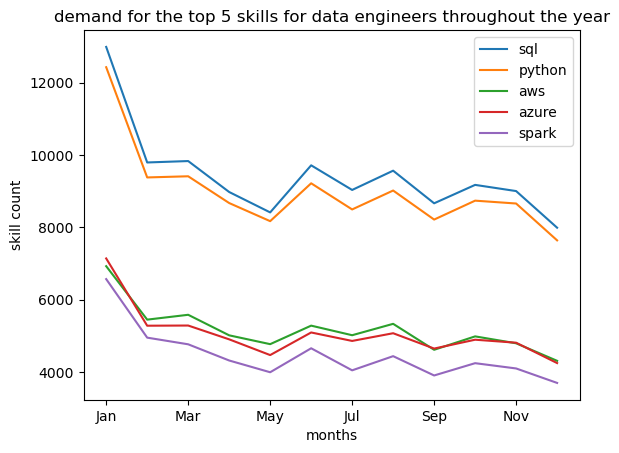

In [8]:
#creating a line graph that displays the demand for the top 5 skills for data engineers throughout the year
df_pivot.iloc[:, 0:5].plot(kind='line')
plt.xlabel('months')
plt.ylabel('skill count')
plt.title('demand for the top 5 skills for data engineers throughout the year')
plt.legend()
plt.show()

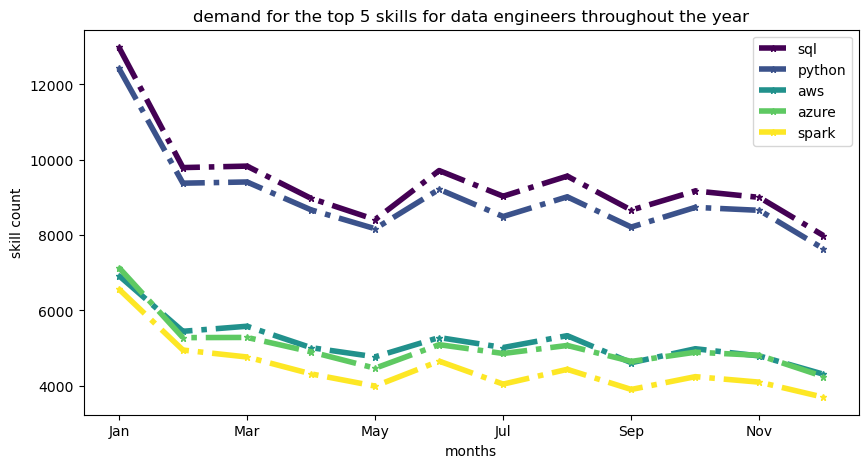

In [24]:
#customizing this line graph
df_pivot.iloc[:, 0:5].plot(kind='line', linewidth=4,linestyle='-.', colormap='viridis', 
                           marker='*', markersize=5, figsize=(10,5))
plt.xlabel('months')
plt.ylabel('skill count')
plt.title('demand for the top 5 skills for data engineers throughout the year')
plt.figsize=(10,20)
plt.legend()
plt.show()

In [31]:
#CUSTOMIZING SCATTER PLOTS
#Filtering Data analyst jobs
df_da=df[df['job_title_short']=='Data Analyst']
#exploding skills column
df_da=df_da.explode('job_skills').copy()

In [33]:
# creating a new dataframe that groups skill count and median yearly salary
job_stats=df_da.groupby('job_skills').agg(skill_count=('job_skills','count'),median_salary=('salary_year_avg','median'))

In [ ]:
# sorting the dataframe by skill count in descending order
job_stats=job_stats.sort_values(by='skill_count',ascending=False).head(20)

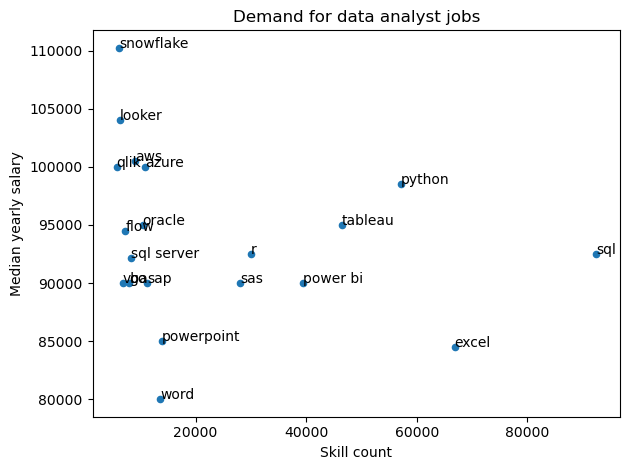

In [ ]:
#plotting a scatter plot that displays the count and median salary associated with the top 20 skills for data analysts
job_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Skill count')
plt.ylabel('Median yearly salary')
plt.title('Demand for data analyst jobs')

#creating labels for the datapoints
for i, txt in enumerate(job_stats.index):
    plt.text(job_stats['skill_count'].iloc[i], job_stats['median_salary'].iloc[i], txt)

plt.tight_layout()
plt.show()

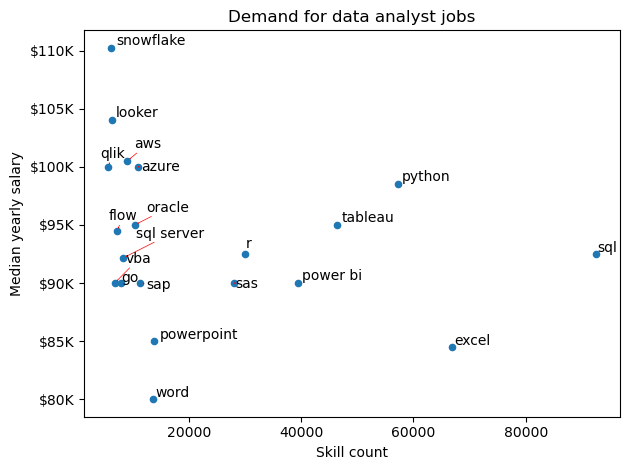

In [51]:
#customizing this plot to prevent overlapping datapoints and formatting the Y-axis to represent salary in USD
from adjustText import adjust_text
job_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Skill count')
plt.ylabel('Median yearly salary')
plt.title('Demand for data analyst jobs')
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

#creating labels for the datapoints
skills=[]
for i, txt in enumerate(job_stats.index):
    skills.append(plt.text(job_stats['skill_count'].iloc[i], job_stats['median_salary'].iloc[i], txt))

adjust_text(skills,arrowprops=dict(arrowstyle='->',color='red',lw=0.5))

plt.tight_layout()
plt.show()